# **Large Language Models Lab(MCSE642P)**

# LSTM
**SHRIHARIHARAN S (24MCS1058)**

**M.TECH CSE 1ST YEAR**




 ---------------------

*we have taken the Fashion_mnist dataset and developed the different CNN models with various dense layers and various epochs and check the performance of the each CNN model*

In [1]:
from keras.layers import Activation, Dense, Dropout, SpatialDropout1D
from keras.layers import Embedding
from keras.layers import LSTM
from keras.models import Sequential
from keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
import collections
import matplotlib.pyplot as plt
import nltk
import numpy as np
import os

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od

In [4]:
!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {"username":"shrihariharanshankar","key":"1b69e9ef19d9ea201b09d3a99c9cc6d5"}
import json

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d https://www.kaggle.com/c/si650winter11/data

Invalid dataset specification https://www.kaggle.com/c/si650winter11/data


In [6]:
import kaggle

In [7]:
from google.colab import files

files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"shrihariharanshankar","key":"1b69e9ef19d9ea201b09d3a99c9cc6d5"}'}

In [8]:
!kaggle competitions download -c si650winter11

  0% 0.00/506k [00:00<?, ?B/s]
100% 506k/506k [00:00<00:00, 89.2MB/s]


In [9]:
!unzip -q /content/si650winter11.zip -d Dataset

In [10]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [11]:
#preprocssing to know how many unique words there are in the corpus and how many words are there in each sentence
maxlen = 0
word_freqs = collections.Counter()
num_recs = 0
ftrain = open('/content/Dataset/training.txt', 'r')
for line in ftrain:
  label, sentence = line.strip().split("\t")
  #words = nltk.word_tokenize(sentence.decode("ascii", "ignore").lower())
  words = nltk.word_tokenize(sentence.lower())
  if len(words) > maxlen:
    maxlen = len(words)
  for word in words:
      word_freqs[word] += 1
  num_recs += 1
ftrain.close()

In [12]:
word_freqs

Counter({'the': 3221,
         'da': 1998,
         'vinci': 2001,
         'code': 1994,
         'book': 135,
         'is': 1521,
         'just': 287,
         'awesome': 1126,
         '.': 3364,
         'this': 213,
         'was': 1179,
         'first': 104,
         'clive': 1,
         'cussler': 1,
         'i': 4707,
         "'ve": 11,
         'ever': 96,
         'read': 113,
         ',': 4194,
         'but': 295,
         'even': 27,
         'books': 28,
         'like': 974,
         'relic': 1,
         'and': 2150,
         'were': 96,
         'more': 103,
         'plausible': 1,
         'than': 14,
         'liked': 101,
         'a': 1305,
         'lot': 22,
         'it': 899,
         'ultimatly': 1,
         'did': 33,
         "n't": 224,
         'seem': 1,
         'to': 808,
         'hold': 2,
         "'s": 629,
         'own': 4,
         'that': 718,
         'not': 198,
         'an': 225,
         'exaggeration': 1,
         ')': 44,
         '

In [13]:
len(word_freqs)

2268

In [14]:
maxlen

42

In [15]:
num_recs

7086

In [16]:
#BASED ON PRECEEDING ESTIMATE WE SET THE VALUES
MAX_FEATURES = 2000 #remaining words are out of vocabulary words OOV
MAX_SENTENCE_LENGTH = 40  #sets a fixed sequence length and zero pad shorter or longer sequence

In [17]:
#creating pair of lookup tables - word2index and index2word
vocab_size = min(MAX_FEATURES, len(word_freqs)) + 2   #vocabulary of size 2002
word2index = {x[0]: i+2 for i, x in enumerate(word_freqs.most_common(MAX_FEATURES))}
word2index["PAD"] = 0
word2index["UNK"] = 1
index2word = {v:k for k, v in word2index.items()}

In [18]:
#convert our input sentences to word index sequences, pad them to the MAX_SENTENCE_LENGTH words
X = np.empty((num_recs, ), dtype=list)
y = np.zeros((num_recs, ))
i = 0
ftrain = open('/content/Dataset/training.txt', 'r')
for line in ftrain:
  label, sentence = line.strip().split("\t")
  #words = nltk.word_tokenize(sentence.decode("ascii", "ignore").lower())
  words = nltk.word_tokenize(sentence.lower())
  seqs = []
  for word in words:
    if word in word2index:
      seqs.append(word2index[word])
    else:
      seqs.append(word2index["UNK"])
  X[i] = seqs
  y[i] = int(label)
  i += 1
ftrain.close()
X = sequence.pad_sequences(X, maxlen=MAX_SENTENCE_LENGTH)

In [19]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
#initializing variables
EMBEDDING_SIZE = 128
HIDDEN_LAYER_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 10

In [21]:
#model building
model = Sequential()
model.add(Embedding(vocab_size, EMBEDDING_SIZE,
input_length=MAX_SENTENCE_LENGTH))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(HIDDEN_LAYER_SIZE, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1))
model.add(Activation("sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
model.compile(loss="binary_crossentropy", optimizer="adam",
metrics=["accuracy"])

In [23]:
#train the network
history = model.fit(Xtrain, ytrain, batch_size=BATCH_SIZE, epochs=NUM_EPOCHS,
validation_data=(Xtest, ytest))

Epoch 1/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.7776 - loss: 0.4155 - val_accuracy: 0.9746 - val_loss: 0.0715
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 25s 140ms/step - accuracy: 0.9924 - loss: 0.0281 - val_accuracy: 0.9866 - val_loss: 0.0393
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 147ms/step - accuracy: 0.9994 - loss: 0.0049 - val_accuracy: 0.9817 - val_loss: 0.0510
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 39s 137ms/step - accuracy: 0.9969 - loss: 0.0105 - val_accuracy: 0.9901 - val_loss: 0.0355
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 137ms/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 0.9908 - val_loss: 0.0424
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.9908 - val_loss: 0.0428
Epoch 7/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - accuracy: 0.9992 - loss: 0.0024 - val_accuracy: 0.9922 - val_loss: 0.0392
Epoch 8/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 40s 133ms/step - accuracy: 0.9997 - loss: 0

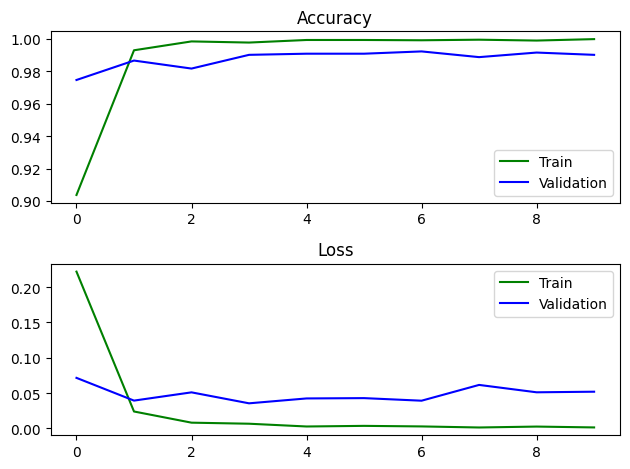

In [24]:
#plot accuracy and loss
plt.subplot(211)
plt.title("Accuracy")
plt.plot(history.history["accuracy"], color="g", label="Train")
plt.plot(history.history["val_accuracy"], color="b", label="Validation")
plt.legend(loc="best")
plt.subplot(212)
plt.title("Loss")
plt.plot(history.history["loss"], color="g", label="Train")
plt.plot(history.history["val_loss"], color="b", label="Validation")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [25]:
#evaluate
score, acc = model.evaluate(Xtest, ytest, batch_size=BATCH_SIZE)
print("Test score: %.3f, accuracy: %.3f" % (score, acc))


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9923 - loss: 0.0455
Test score: 0.052, accuracy: 0.990


In [26]:
#predict 0-Negative and 1-Positive
for i in range(20):
  idx = np.random.randint(len(Xtest))
  xtest = Xtest[idx].reshape(1,40)
  ylabel = ytest[idx]
  ypred = model.predict(xtest)[0][0]
  sent = " ".join([index2word[x] for x in xtest[0].tolist() if x != 0])
  print("%d\t%d\t%s" % (round(ypred), ylabel, sent))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
0	0	i thought brokeback mountain was an awful movie .
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1	1	i love brokeback mountain .
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1	1	because i would like to make friends who like the same things i like , and i really like harry potter , so i thought that joining a community like this would be a good start .
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1	1	harry potter is awesome i do n't care if anyone says differently ! ..
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
0	0	i hate harry potter , it 's retarted , gay and stupid and there 's only one black guy ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1	1	harry potter is awesome i do n't care if anyone says differently ! ..
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1	1	man i loved brokeback mountain !
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1	1	brokeback mountain was so awesome .
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
0	0	brokeback mountain sucked ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


**Enhanced LSTM for Sentiment Analysis**

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, LSTM, Embedding, Bidirectional, Input, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Attention Layer
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(shape=(1,), initializer='zeros', trainable=True)

    def call(self, inputs):
        e = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = inputs * a
        return tf.reduce_sum(output, axis=1)

# Parameters
max_words = 10000  # Vocabulary size
max_len = 200      # Max sequence length
embedding_dim = 100

# Load and Preprocess Training Data
training_file_path = "/content/Dataset/training.txt"
test_file_path = "/content/Dataset/testdata.txt"

def load_training_data(file_path):
    texts, labels = [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                labels.append(int(parts[0]))
                texts.append(parts[1])
    return texts, np.array(labels)

train_texts, train_labels = load_training_data(training_file_path)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)
train_sequences = tokenizer.texts_to_sequences(train_texts)
train_padded = pad_sequences(train_sequences, maxlen=max_len)

# Model with Bidirectional LSTM and Attention
input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len)(input_layer)
bi_lstm = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(embedding_layer)
attention = Attention()(bi_lstm)
dense1 = Dense(64, activation='relu')(attention)
dropout = Dropout(0.5)(dense1)
output_layer = Dense(1, activation='sigmoid')(dropout)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train Model
model.fit(train_padded, train_labels, epochs=5, batch_size=32, validation_split=0.2)

# Load and Preprocess Test Data
def load_test_data(file_path):
    texts = []
    with open(file_path, 'r', encoding='utf-8') as f:
        texts = f.readlines()
    return [text.strip() for text in texts]

test_texts = load_test_data(test_file_path)
test_sequences = tokenizer.texts_to_sequences(test_texts)
test_padded = pad_sequences(test_sequences, maxlen=max_len)

# Predict Sentiment
test_predictions = model.predict(test_padded)
test_sentiments = ['Positive' if pred > 0.5 else 'Negative' for pred in test_predictions]

# Display Sample Predictions
for text, sentiment in zip (test_texts[:15], test_sentiments[:15]):
    print(f"Text: {text}\nSentiment: {sentiment}\n")


Epoch 1/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7173 - loss: 0.5696 - val_accuracy: 0.3237 - val_loss: 3.1950
Epoch 2/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9028 - loss: 0.2418 - val_accuracy: 0.3237 - val_loss: 4.0508
Epoch 3/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9665 - loss: 0.1326 - val_accuracy: 0.3329 - val_loss: 4.2776
Epoch 4/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9729 - loss: 0.1085 - val_accuracy: 0.3131 - val_loss: 5.3211
Epoch 5/5
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9960 - loss: 0.0288 - val_accuracy: 0.3202 - val_loss: 5.4632
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step
Text: " I don't care what anyone says, I like Hillary Clinton.
Sentiment: Positive

Text: have an awesome time at purdue!..
Sentiment: Positive

Text: Yep, I'm still in London, which is pretty awesome: P Remind me to post the million and one pictures that I took when I get back to Markham!...
Sentiment: Positive

Te

**Inference for Enhanced LSTM for Sentiment Analysis:**


*    **Preprocessing:** The input text needs to be tokenized and padded to the same length as used during training (200 words in this case). This ensures consistency between training and inference.

*   **Prediction:** The trained LSTM model takes the processed text as input and outputs a probability score between 0 and 1.
Interpretation: A probability score greater than 0.5 is classified as positive sentiment, while a score below 0.5 is classified as negative sentiment.

*   For example, if we pass the sentence "I absolutely loved the movie!", the model processes it, predicts a probability of 0.92, and classifies it as positive sentiment. If we input "The movie was terrible and boring", the model might return 0.15, categorizing it as negative sentiment.

